In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
def distance(x1,x2,y1,y2):
    d = np.round(np.sqrt((x1-x2)**2 + (y1-y2)**2), 3)
    # cord = (x1,y1)
    return d

def centroid(x, y):
    return np.round(np.mean(x), 3), np.round(np.mean(y), 3)

def initialize_centers(x, y, k=3):

    cx = np.random.uniform(x.min(), x.max(), k)
    cy = np.random.uniform(y.min(), y.max(), k)

    return np.round(cx, 3), np.round(cy, 3)
    

def assign_clusters(x, y, cx, cy):
    dists = np.array([distance(cx[i], x, cy[i], y) for i in range(len(cx))])
    return np.argmin(dists, axis=0)

def update_centers(x, y, labels, cx, cy, k):
    new_cx, new_cy = cx.copy(), cy.copy()
    for i in range(k):
        mask = labels == i
        if mask.any():
            new_cx[i], new_cy[i] = centroid(x[mask], y[mask])
    return new_cx, new_cy

def compute_inertia(x, y, labels, cx, cy):
    return np.sum((x - cx[labels])**2 + (y - cy[labels])**2)

def kmeans_fit(x, y, k=3, max_iter=300):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    cx, cy = initialize_centers(x, y, k)
    history = [(cx.copy(), cy.copy())]
    for _ in range(max_iter):
        labels = assign_clusters(x, y, cx, cy)
        new_cx, new_cy = update_centers(x, y, labels, cx, cy, k)
        history.append((new_cx.copy(), new_cy.copy()))
        if np.array_equal(new_cx, cx) and np.array_equal(new_cy, cy):
            break
        cx, cy = new_cx, new_cy
    labels = assign_clusters(x, y, cx, cy)
    inertia = compute_inertia(x, y, labels, cx, cy)
    return labels, cx, cy, inertia, history


In [26]:
df = pd.read_csv("Iris.csv")

In [27]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
df = df.drop("Id", axis=1)

In [29]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [30]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


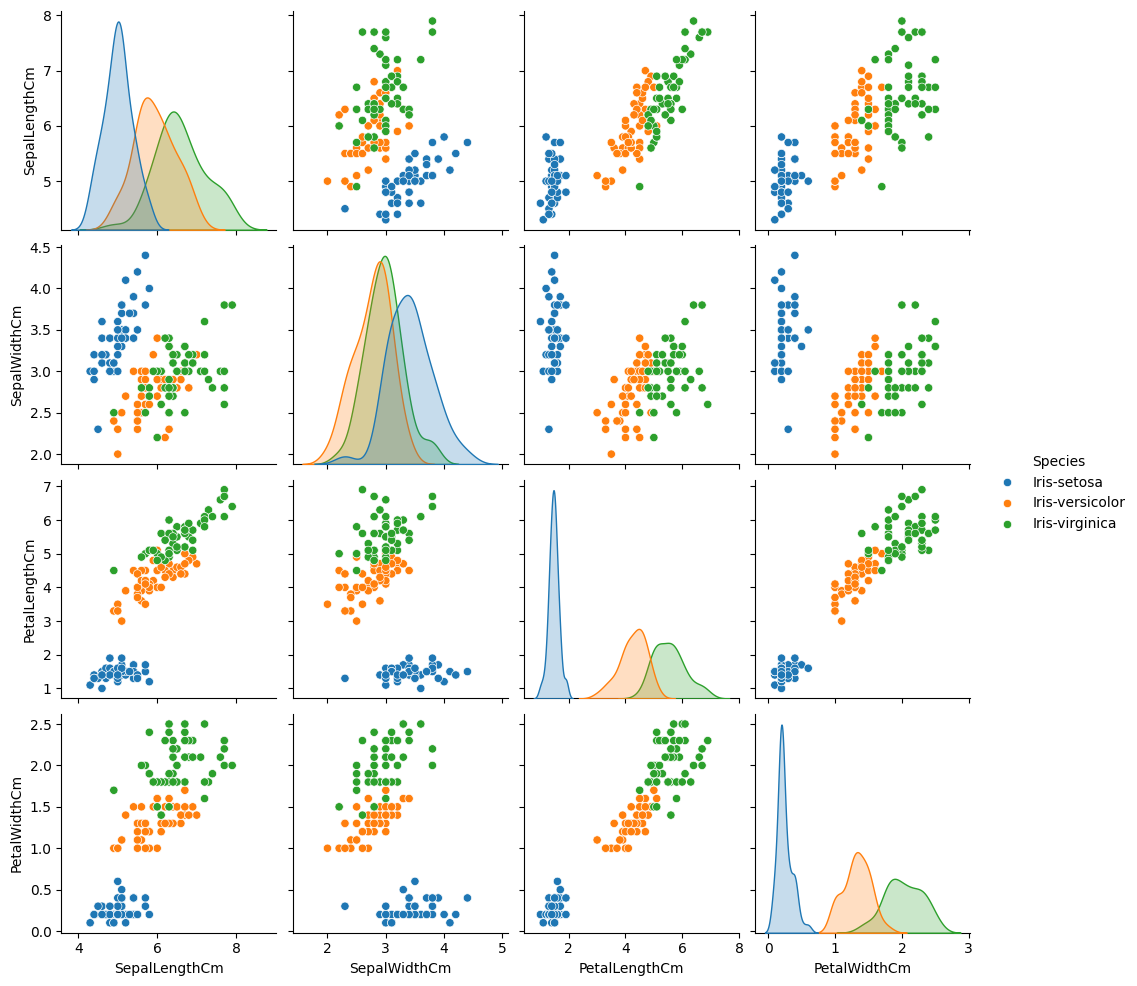

In [31]:
sns.pairplot(df, hue="Species")

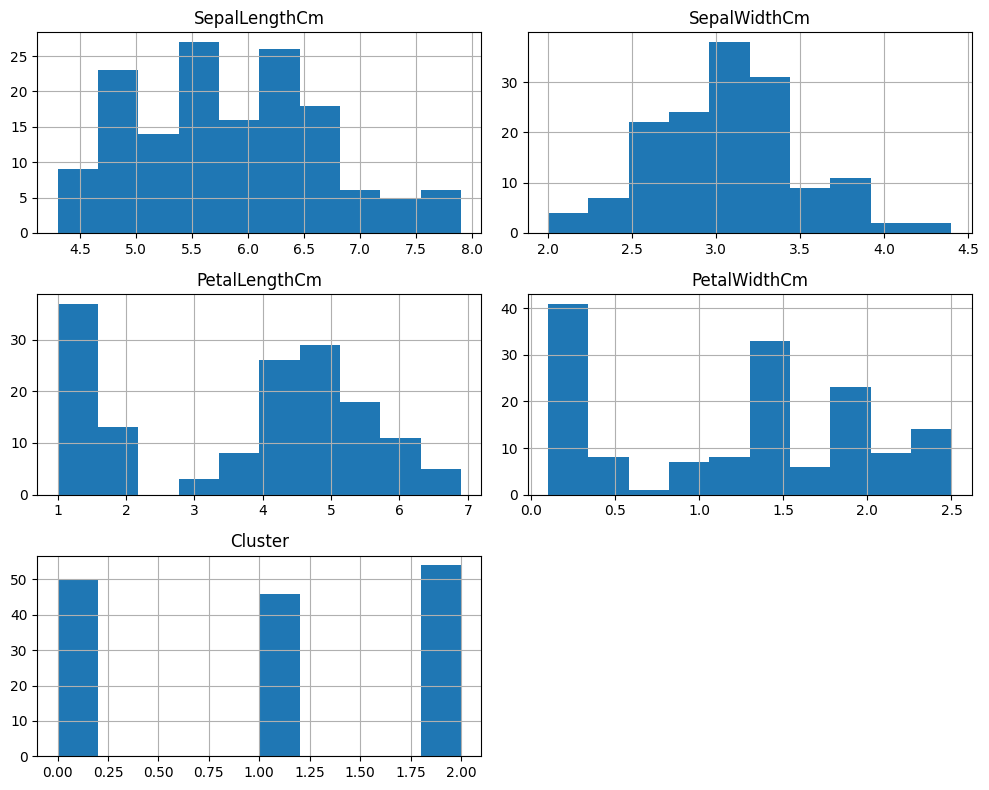

In [47]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

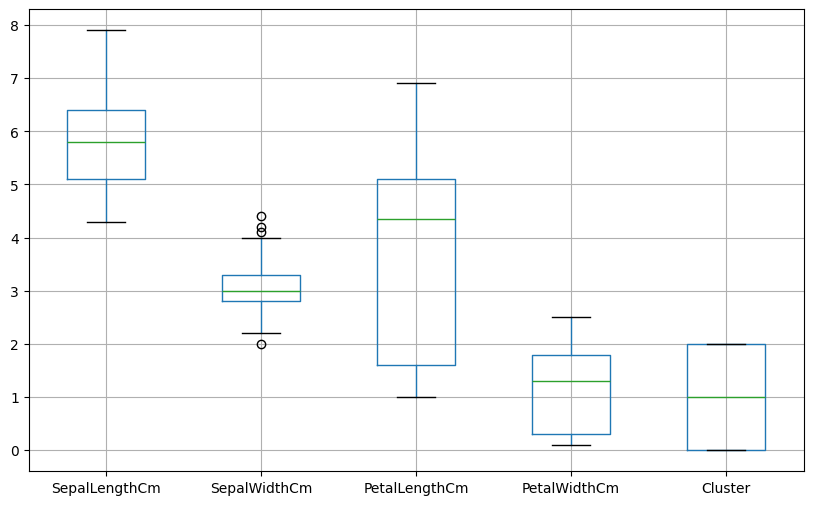

In [48]:
df.boxplot(figsize=(10, 6))
plt.show()

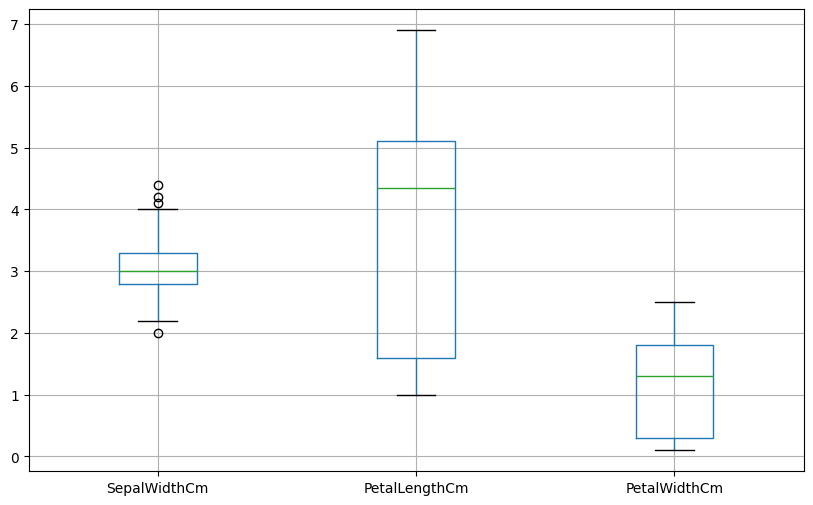

In [49]:
df.iloc[:, 1:-1].boxplot(figsize=(10, 6))
plt.show()

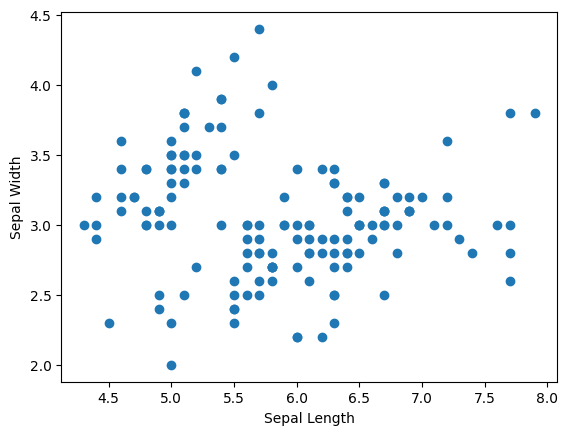

In [50]:
plt.scatter(df["SepalLengthCm"], df["SepalWidthCm"])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

In [32]:
features = df.columns[:-1]

In [33]:
x = df["SepalLengthCm"]
y = df["PetalWidthCm"]

In [34]:
cx, cy = initialize_centers(x,y)
distall = []
for i in range(len(cx)):
    dist = distance(cx[i], x, cy[i], y)
    distall.append(dist)

print(distall)

[0      1.705
1      1.646
2      1.610
3      1.602
4      1.673
       ...  
145    2.248
146    1.794
147    2.001
148    1.764
149    1.391
Length: 150, dtype: float64, 0      2.319
1      2.519
2      2.718
3      2.818
4      2.419
       ...  
145    2.268
146    2.077
147    2.066
148    2.472
149    2.243
Length: 150, dtype: float64, 0      2.612
1      2.722
2      2.842
3      2.905
4      2.666
       ...  
145    0.268
146    0.553
147    0.430
148    0.293
149    0.844
Length: 150, dtype: float64]


In [35]:
a,b = initialize_centers(x,y)

In [36]:
a

array([7.297, 5.064, 4.955])

In [37]:
np.random.seed(42)
labels, cx, cy, inertia, history = kmeans_fit(x, y, k=3)
print(cx, cy)
print(inertia)
print(len(history) - 1)

[5.006 6.857 5.893] [0.302 2.012 1.463]
32.768038
13


In [38]:
df["Cluster"] = labels
print(pd.crosstab(df["Species"], df["Cluster"]))

Cluster           0   1   2
Species                    
Iris-setosa      50   0   0
Iris-versicolor   4   7  39
Iris-virginica    0  35  15


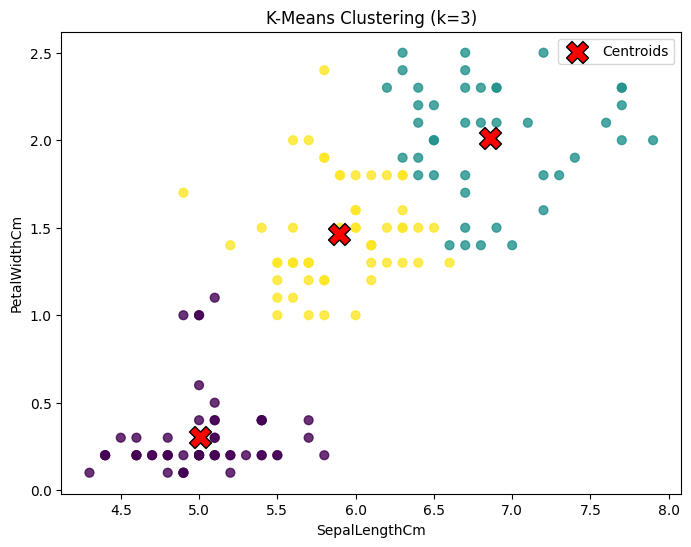

In [39]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=labels, cmap="viridis", s=40, alpha=0.8)
plt.scatter(cx, cy, c="red", marker="X", s=250, edgecolors="black", label="Centroids")
plt.xlabel("SepalLengthCm")
plt.ylabel("PetalWidthCm")
plt.title("K-Means Clustering (k=3)")
plt.legend()
plt.show()

In [40]:
x = df["PetalLengthCm"]
y = df["PetalWidthCm"]

[1.464 5.626 4.293] [0.244 2.048 1.359]
31.4293
9
Cluster           0   1   2
Species                    
Iris-setosa      50   0   0
Iris-versicolor   0   2  48
Iris-virginica    0  44   6


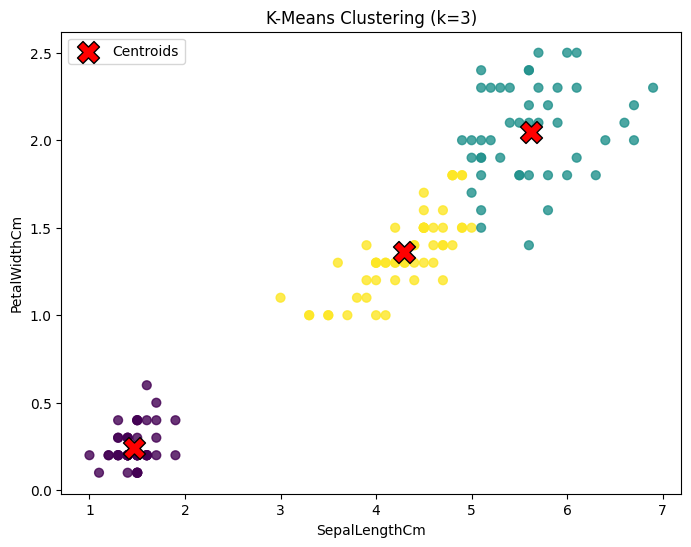

In [41]:
np.random.seed(42)
labels, cx, cy, inertia, history = kmeans_fit(x, y, k=3)
print(cx, cy)
print(inertia)
print(len(history) - 1)
df["Cluster"] = labels
print(pd.crosstab(df["Species"], df["Cluster"]))
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=labels, cmap="viridis", s=40, alpha=0.8)
plt.scatter(cx, cy, c="red", marker="X", s=250, edgecolors="black", label="Centroids")
plt.xlabel("SepalLengthCm")
plt.ylabel("PetalWidthCm")
plt.title("K-Means Clustering (k=3)")
plt.legend()
plt.show()

In [42]:
cx, cy = initialize_centers(x,y)

In [45]:
a = assign_clusters(x,y,cx,cy)

In [46]:
a

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])